In [85]:
import numpy as np
import pandas as pd

In [86]:
df=pd.read_csv('aug_train.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [87]:
print(df.describe())

        enrollee_id  city_development_index  training_hours        target
count  19158.000000            19158.000000    19158.000000  19158.000000
mean   16875.358179                0.828848       65.366896      0.249348
std     9616.292592                0.123362       60.058462      0.432647
min        1.000000                0.448000        1.000000      0.000000
25%     8554.250000                0.740000       23.000000      0.000000
50%    16982.500000                0.903000       47.000000      0.000000
75%    25169.750000                0.920000       88.000000      0.000000
max    33380.000000                0.949000      336.000000      1.000000


In [88]:
print(df.isnull().sum())
print(df['company_size'].value_counts())

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64
company_size
50-99        3083
100-500      2571
10000+       2019
10/49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64


In [89]:
df['company_size']=df['company_size'].fillna(df['company_size'].mode()[0])
df['company_size']=df['company_size'].map({
    "<10":1,
    "10/49":2,
    "50-99":3,
    "100-500":4,
    "500-999":5,
    "1000-4999":6,
    "5000-9999":7,
    "10000+":8
})

In [90]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,3,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,3,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,3,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,3,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,3,Funded Startup,4,8,0.0


In [91]:
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['company_type']=df['company_type'].fillna(df['company_type'].mode()[0])

In [92]:
print(df.isnull().sum())

enrollee_id                  0
city                         0
city_development_index       0
gender                       0
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size                 0
company_type                 0
last_new_job               423
training_hours               0
target                       0
dtype: int64


In [93]:
major_mode=df['major_discipline'].mode()[0]
df['major_discipline']=df['major_discipline'].fillna(major_mode)
print(df.isnull().sum())

enrollee_id                 0
city                        0
city_development_index      0
gender                      0
relevent_experience         0
enrolled_university       386
education_level           460
major_discipline            0
experience                 65
company_size                0
company_type                0
last_new_job              423
training_hours              0
target                      0
dtype: int64


In [94]:
print(df.nunique())

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64


In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  19158 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        19158 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            19158 non-null  int64  
 10  company_type            19158 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(3), object(9)
mem

In [96]:
print(df['experience'].unique())
print(df.isnull().sum())

['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
enrollee_id                 0
city                        0
city_development_index      0
gender                      0
relevent_experience         0
enrolled_university       386
education_level           460
major_discipline            0
experience                 65
company_size                0
company_type                0
last_new_job              423
training_hours              0
target                      0
dtype: int64


In [97]:
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18014 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18014 non-null  int64  
 1   city                    18014 non-null  object 
 2   city_development_index  18014 non-null  float64
 3   gender                  18014 non-null  object 
 4   relevent_experience     18014 non-null  object 
 5   enrolled_university     18014 non-null  object 
 6   education_level         18014 non-null  object 
 7   major_discipline        18014 non-null  object 
 8   experience              18014 non-null  object 
 9   company_size            18014 non-null  int64  
 10  company_type            18014 non-null  object 
 11  last_new_job            18014 non-null  object 
 12  training_hours          18014 non-null  int64  
 13  target                  18014 non-null  float64
dtypes: float64(2), int64(3), object(9)
memory u

In [98]:
print(df.nunique())

enrollee_id               18014
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64


In [99]:
print(df['last_new_job'].unique())

['1' '>4' 'never' '4' '3' '2']


In [100]:
df_before_encoding=df.copy()
df=df.drop(columns=['enrollee_id','city','gender'])
df=pd.get_dummies(df,columns=['major_discipline','education_level','enrolled_university',
                              'relevent_experience','company_type','experience'])
boolcol=df.select_dtypes(include='bool').columns
df[boolcol]=df[boolcol].astype(int)
df['last_new_job']=df['last_new_job'].replace({'never':'0','>4':5}).astype(int)

In [101]:
print(df.isnull().sum())

city_development_index                         0
company_size                                   0
last_new_job                                   0
training_hours                                 0
target                                         0
major_discipline_Arts                          0
major_discipline_Business Degree               0
major_discipline_Humanities                    0
major_discipline_No Major                      0
major_discipline_Other                         0
major_discipline_STEM                          0
education_level_Graduate                       0
education_level_High School                    0
education_level_Masters                        0
education_level_Phd                            0
education_level_Primary School                 0
enrolled_university_Full time course           0
enrolled_university_Part time course           0
enrolled_university_no_enrollment              0
relevent_experience_Has relevent experience    0
relevent_experience_

In [102]:
df.head()

,city_development_index,company_size,last_new_job,training_hours,target,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,...,experience_20,experience_3,experience_4,experience_5,experience_6,experience_7,experience_8,experience_9,experience_<1,experience_>20
0,0.920,3,1,36,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.776,3,5,47,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.624,3,0,83,0.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.767,3,4,8,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,0.764,3,1,24,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
# df['experience']=df['experience'].replace({'<1':'0','>20':'21'})
# df['experience']=df['experience'].astype(int)


In [104]:
df.head()

,city_development_index,company_size,last_new_job,training_hours,target,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,...,experience_20,experience_3,experience_4,experience_5,experience_6,experience_7,experience_8,experience_9,experience_<1,experience_>20
0,0.920,3,1,36,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.776,3,5,47,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.624,3,0,83,0.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.767,3,4,8,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,0.764,3,1,24,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18014 entries, 0 to 19157
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   city_development_index                       18014 non-null  float64
 1   company_size                                 18014 non-null  int64  
 2   last_new_job                                 18014 non-null  int64  
 3   training_hours                               18014 non-null  int64  
 4   target                                       18014 non-null  float64
 5   major_discipline_Arts                        18014 non-null  int64  
 6   major_discipline_Business Degree             18014 non-null  int64  
 7   major_discipline_Humanities                  18014 non-null  int64  
 8   major_discipline_No Major                    18014 non-null  int64  
 9   major_discipline_Other                       18014 non-null  int64  
 10  maj

In [106]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['target'])
y=df['target']


In [107]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)


In [108]:
scaling_col = ['city_development_index', 'company_size', 'last_new_job', 'training_hours']
for col in scaling_col:
    mean=x_train[col].mean()
    std=x_train[col].std()
    x_train[col] = (x_train[col]-mean)/std
    x_test[col] = (x_test[col]-mean)/std

In [124]:
x_train.head()

,city_development_index,company_size,last_new_job,training_hours,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,...,experience_20,experience_3,experience_4,experience_5,experience_6,experience_7,experience_8,experience_9,experience_<1,experience_>20
4750,0.875296,-0.460432,1.179804,-0.988932,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7944,0.719021,1.616177,1.778051,0.059282,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
11341,-1.715591,-0.460432,1.778051,0.441963,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
15166,0.875296,0.058720,-0.614935,-0.506421,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
12090,0.546295,-0.460432,-0.614935,-1.022208,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,f1_score,precision_score,classification_report

In [110]:
logistic_model=LogisticRegression(max_iter=10000,random_state=42,class_weight="balanced")
logistic_model.fit(x_train,y_train)
y_prediction=logistic_model.predict(x_test)
accuracy_log=accuracy_score(y_test,y_prediction)
matrix_log=confusion_matrix(y_test,y_prediction)
recall_log=recall_score(y_test,y_prediction)
f1_log=f1_score(y_test,y_prediction)
precision_log=precision_score(y_test,y_prediction)

In [111]:
print("acc : ",accuracy_log)
print("*"*30)
print(matrix_log)
print("*"*30)
print("precision : ",precision_log)
print("*"*30)
print("recall : ",recall_log)
print("*"*30)
print("f1_score : ",f1_log)
print("*"*30)
print(classification_report(y_test,y_prediction))

acc :  0.7099639189564252
******************************
[[1977  742]
 [ 303  581]]
******************************
precision :  0.43915343915343913
******************************
recall :  0.6572398190045249
******************************
f1_score :  0.526506570004531
******************************
              precision    recall  f1-score   support

         0.0       0.87      0.73      0.79      2719
         1.0       0.44      0.66      0.53       884

    accuracy                           0.71      3603
   macro avg       0.65      0.69      0.66      3603
weighted avg       0.76      0.71      0.73      3603



In [112]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_leaf=2,
                                  random_state=42,class_weight="balanced")
rf_model.fit(x_train, y_train)
y_prediction_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_prediction_rf)
matrix_rf = confusion_matrix(y_test, y_prediction_rf)
recall_rf = recall_score(y_test, y_prediction_rf)
f1_rf = f1_score(y_test, y_prediction_rf)
precision_rf = precision_score(y_test, y_prediction_rf)

In [113]:
print("acc : ",accuracy_rf)
print("*"*30)
print(matrix_rf)
print("*"*30)
print("precision : ",precision_rf)
print("*"*30)
print("recall : ",recall_rf)
print("*"*30)
print("f1_score : ",f1_rf)
print("*"*30)
print(classification_report(y_test,y_prediction))

acc :  0.7582570080488482
******************************
[[2127  592]
 [ 279  605]]
******************************
precision :  0.5054302422723476
******************************
recall :  0.6843891402714932
******************************
f1_score :  0.5814512253724171
******************************
              precision    recall  f1-score   support

         0.0       0.87      0.73      0.79      2719
         1.0       0.44      0.66      0.53       884

    accuracy                           0.71      3603
   macro avg       0.65      0.69      0.66      3603
weighted avg       0.76      0.71      0.73      3603



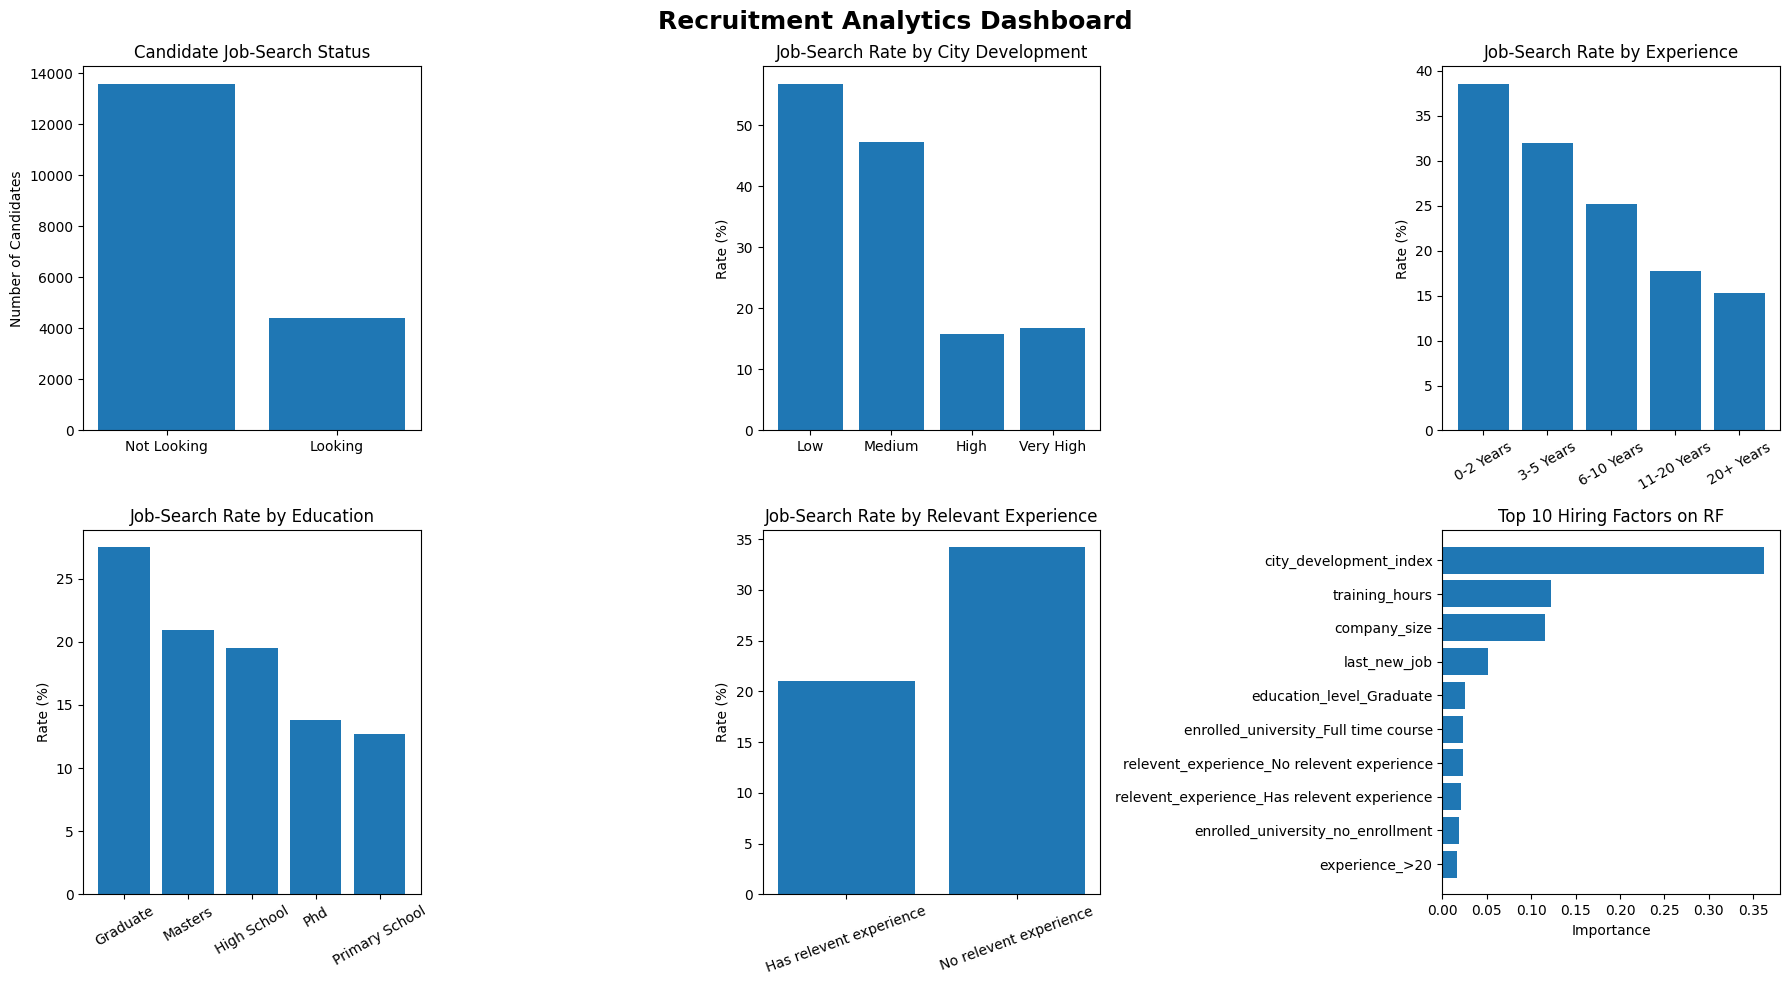

In [125]:
import matplotlib.pyplot as plt
dashboard_df = df_before_encoding.copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    "Recruitment Analytics Dashboard",
    fontsize=18,
    fontweight="bold"
)

# ==========================================
# 1. Target Distribution
# ==========================================

target_counts = dashboard_df["target"].value_counts().sort_index()

axes[0, 0].bar(
    ["Not Looking", "Looking"],
    target_counts.values
)

axes[0, 0].set_title("Candidate Job-Search Status")
axes[0, 0].set_ylabel("Number of Candidates")


# ==========================================
# 2. Job Search Rate by City Development
# ==========================================

dashboard_df["cdi_group"] = pd.cut(
    dashboard_df["city_development_index"],
    bins=[0, 0.6, 0.75, 0.9, 1.0],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

cdi_rate = (
    dashboard_df
    .groupby("cdi_group", observed=False)["target"]
    .mean()
    * 100
)

axes[0, 1].bar(
    cdi_rate.index.astype(str),
    cdi_rate.values
)

axes[0, 1].set_title("Job-Search Rate by City Development")
axes[0, 1].set_ylabel("Rate (%)")


# ==========================================
# 3. Job Search Rate by Experience
# ==========================================

dashboard_df["experience_num"] = (
    dashboard_df["experience"]
    .replace({
        "<1": "0",
        ">20": "21"
    })
    .astype(int)
)

dashboard_df["experience_group"] = pd.cut(
    dashboard_df["experience_num"],
    bins=[-1, 2, 5, 10, 20, 100],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-20 Years",
        "20+ Years"
    ]
)

experience_rate = (
    dashboard_df
    .groupby("experience_group", observed=False)["target"]
    .mean()
    * 100
)

axes[0, 2].bar(
    experience_rate.index.astype(str),
    experience_rate.values
)

axes[0, 2].set_title("Job-Search Rate by Experience")
axes[0, 2].set_ylabel("Rate (%)")

axes[0, 2].tick_params(
    axis="x",
    rotation=30
)


# ==========================================
# 4. Job Search Rate by Education
# ==========================================

education_rate = (
    dashboard_df
    .groupby("education_level")["target"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

axes[1, 0].bar(
    education_rate.index.astype(str),
    education_rate.values
)

axes[1, 0].set_title("Job-Search Rate by Education")
axes[1, 0].set_ylabel("Rate (%)")

axes[1, 0].tick_params(
    axis="x",
    rotation=30
)


# ==========================================
# 5. Relevant Experience
# ==========================================

relevant_rate = (
    dashboard_df
    .groupby("relevent_experience")["target"]
    .mean()
    * 100
)

axes[1, 1].bar(
    relevant_rate.index.astype(str),
    relevant_rate.values
)

axes[1, 1].set_title("Job-Search Rate by Relevant Experience")
axes[1, 1].set_ylabel("Rate (%)")

axes[1, 1].tick_params(
    axis="x",
    rotation=20
)


# ==========================================
# 6. Top 10 Hiring Factors
# ==========================================

top_features = (
    importances
    .head(10)
    .sort_values()
)

axes[1, 2].barh(
    top_features.index,
    top_features.values
)

axes[1, 2].set_title("Top 10 Hiring Factors on RF")
axes[1, 2].set_xlabel("Importance")


plt.tight_layout()
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()

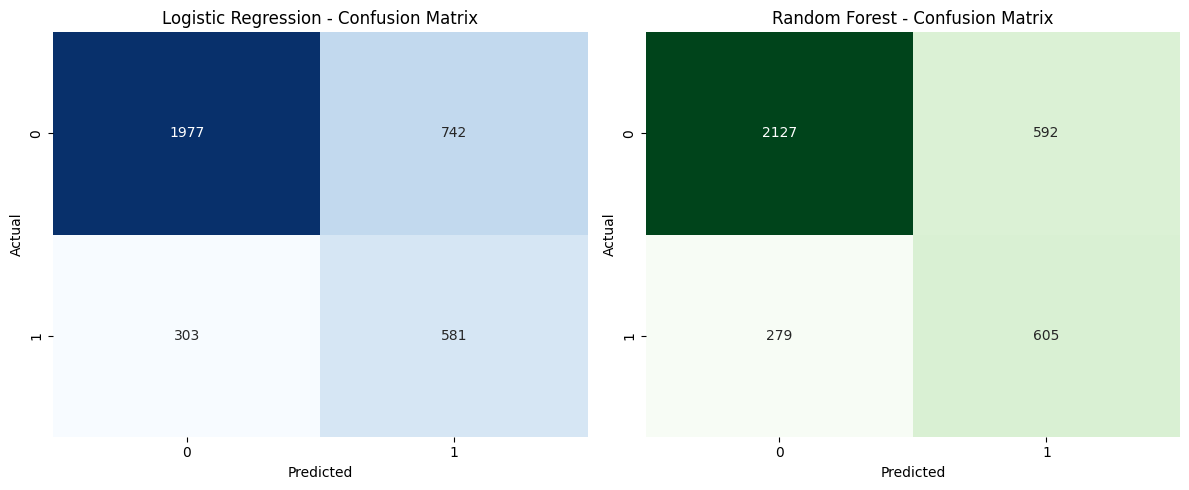

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(
    matrix_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Random Forest
sns.heatmap(
    matrix_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [116]:

import seaborn as sns

# ==========================================
# Performance Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_rf
    ],
    "Precision": [
        precision_log,
        precision_rf
    ],
    "Recall": [
        recall_log,
        recall_rf
    ],
    "F1 Score": [
        f1_log,
        f1_rf
    ]
})

# Convert metrics to percentage
comparison_percent = comparison.copy()

comparison_percent[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = (
    comparison_percent[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ] * 100
).round(2)

print("Model Performance Comparison")

display(comparison_percent)

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,71.00,43.92,65.72,52.65
1,Random Forest,75.83,50.54,68.44,58.15


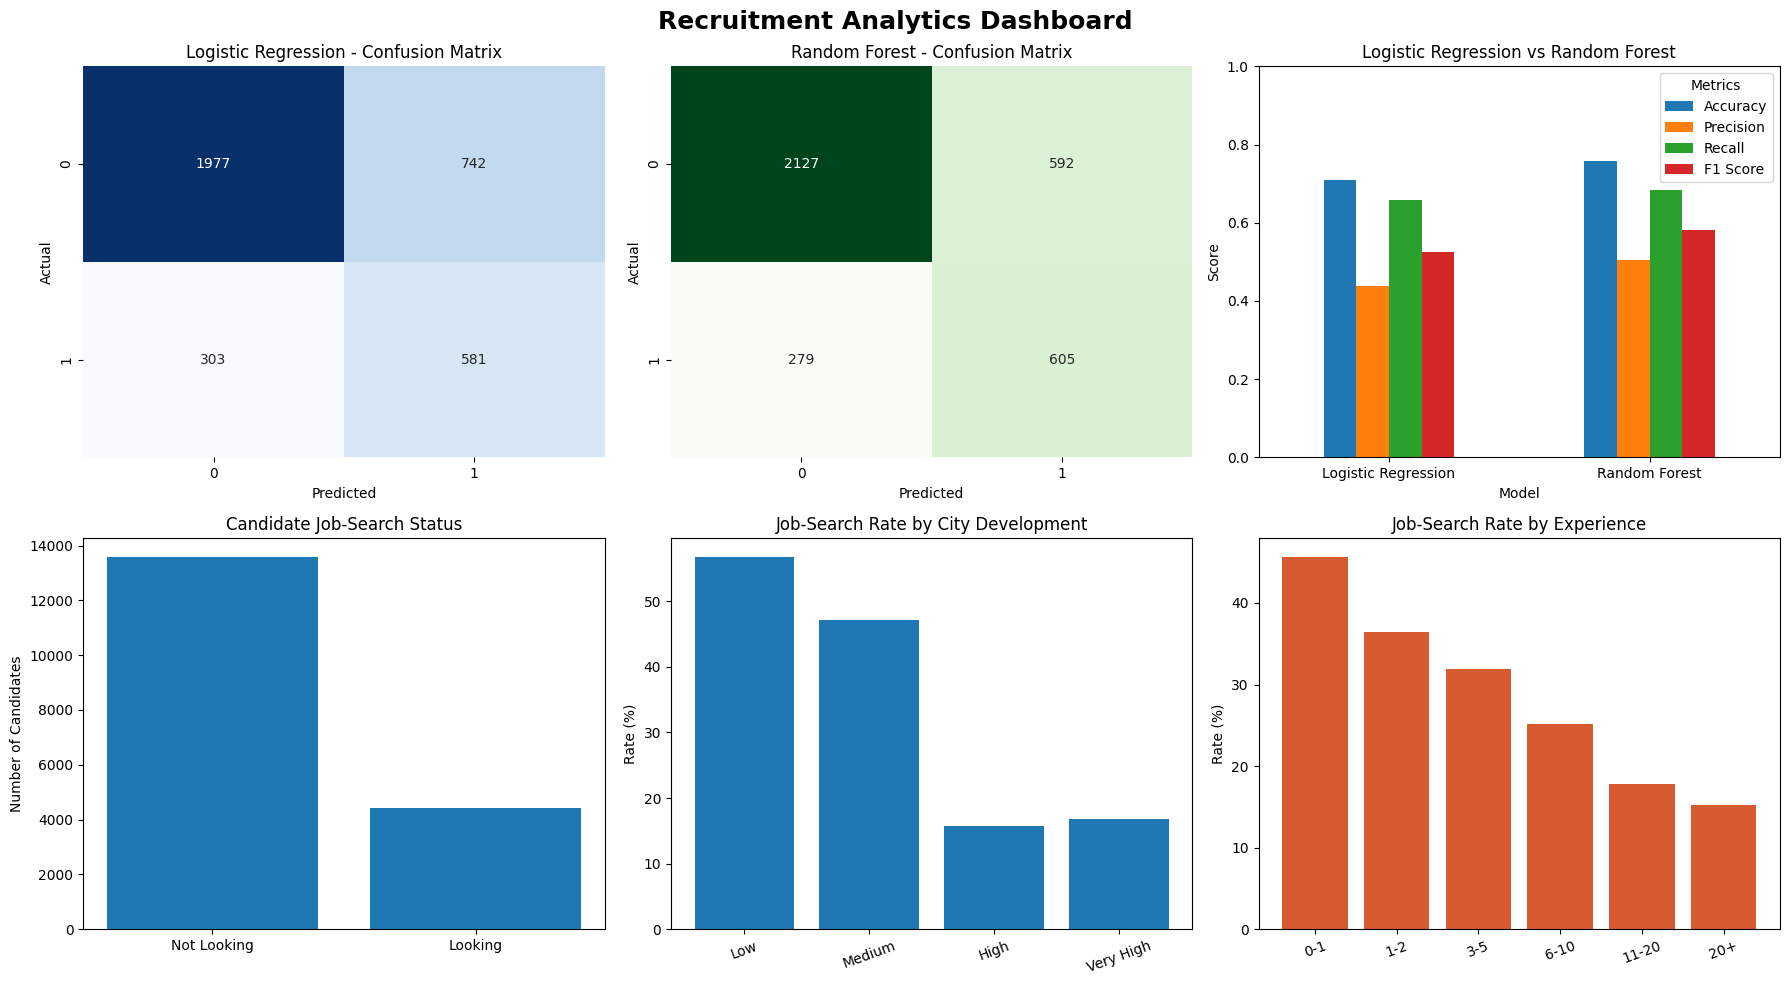

In [117]:
# ==========================================
# Recruitment Dashboard
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    "Recruitment Analytics Dashboard",
    fontsize=18,
    fontweight="bold"
)


# ==========================================
# 1. Logistic Regression Confusion Matrix
# ==========================================

sns.heatmap(
    matrix_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Logistic Regression - Confusion Matrix"
)

axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")


# ==========================================
# 2. Random Forest Confusion Matrix
# ==========================================

sns.heatmap(
    matrix_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Random Forest - Confusion Matrix"
)

axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")


# ==========================================
# 3. Model Performance Comparison
# ==========================================

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    ax=axes[0, 2]
)

axes[0, 2].set_title(
    "Logistic Regression vs Random Forest"
)

axes[0, 2].set_ylabel("Score")
axes[0, 2].set_xlabel("Model")

axes[0, 2].set_ylim(0, 1)

axes[0, 2].tick_params(
    axis="x",
    rotation=0
)

axes[0, 2].legend(
    title="Metrics"
)


# ==========================================
# 4. Target Distribution
# ==========================================

target_counts = (
    df_before_encoding["target"]
    .value_counts()
    .sort_index()
)

axes[1, 0].bar(
    ["Not Looking", "Looking"],
    target_counts.values
)

axes[1, 0].set_title(
    "Candidate Job-Search Status"
)

axes[1, 0].set_ylabel(
    "Number of Candidates"
)


# ==========================================
# 5. Job Search Rate by City Development
# ==========================================

dashboard_df = df_before_encoding.copy()

dashboard_df["city_development_group"] = pd.cut(
    dashboard_df["city_development_index"],
    bins=[0, 0.6, 0.75, 0.9, 1.0],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

city_rate = (
    dashboard_df
    .groupby(
        "city_development_group",
        observed=False
    )["target"]
    .mean()
    * 100
)

axes[1, 1].bar(
    city_rate.index.astype(str),
    city_rate.values
)

axes[1, 1].set_title(
    "Job-Search Rate by City Development"
)

axes[1, 1].set_ylabel(
    "Rate (%)"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=20
)# ==========================================
# 6. Job Search Rate by Experience
# ==========================================

def exp_group(e):
    if e == '<1': return '0-1'
    if e == '>20': return '20+'
    e = int(e)
    if e <= 2: return '1-2'
    if e <= 5: return '3-5'
    if e <= 10: return '6-10'
    return '11-20'

dashboard_df['experience_group'] = dashboard_df['experience'].apply(exp_group)
order = ['0-1','1-2','3-5','6-10','11-20','20+']
exp_rate = dashboard_df.groupby('experience_group')['target'].mean().reindex(order) * 100

axes[1, 2].bar(exp_rate.index.astype(str), exp_rate.values, color='#D85A30')
axes[1, 2].set_title("Job-Search Rate by Experience")
axes[1, 2].set_ylabel("Rate (%)")
axes[1, 2].tick_params(axis="x", rotation=20)


plt.tight_layout()
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [118]:
rf_scores = rf_model.predict_proba(x_test)[:, 1]
rf_ranking = df_before_encoding.loc[
    x_test.index,
    [
        "enrollee_id",
        "city",
        "city_development_index",
        "relevent_experience",
        "education_level",
        "experience",
        "company_size",
        "company_type",
        "last_new_job",
        "training_hours",
        "target"
    ]
].copy()
rf_ranking["job_change_probability"]=(rf_scores * 100).round(2)
top_10_rf=(rf_ranking.sort_values("job_change_probability",ascending=False).head(10).reset_index(drop=True))
top_10_rf.index = top_10_rf.index + 1
top_10_rf.index.name = "Rank"
print("Top 10 Candidates - Random Forest")
display(top_10_rf)

Top 10 Candidates - Random Forest


,enrollee_id,city,city_development_index,relevent_experience,education_level,experience,company_size,company_type,last_new_job,training_hours,target,job_change_probability
Rank,,,,,,,,,,,,
1,18506,city_21,0.624,Has relevent experience,Masters,1,3,Pvt Ltd,1,22,0.0,89.17
2,17541,city_21,0.624,Has relevent experience,Masters,1,3,Pvt Ltd,1,52,0.0,88.60
3,18890,city_21,0.624,No relevent experience,Graduate,1,3,Pvt Ltd,1,78,1.0,88.29
4,1804,city_21,0.624,Has relevent experience,Graduate,6,2,Pvt Ltd,never,22,1.0,87.88
5,13629,city_21,0.624,Has relevent experience,Graduate,1,3,Pvt Ltd,1,27,1.0,87.58
6,20387,city_21,0.624,No relevent experience,Graduate,6,3,Pvt Ltd,1,147,0.0,87.47
7,20704,city_21,0.624,Has relevent experience,Graduate,6,2,Pvt Ltd,never,26,0.0,87.44
8,5132,city_19,0.682,No relevent experience,Graduate,7,3,Pvt Ltd,never,21,1.0,87.38
9,19770,city_11,0.550,No relevent experience,Graduate,5,2,Pvt Ltd,1,102,1.0,87.37


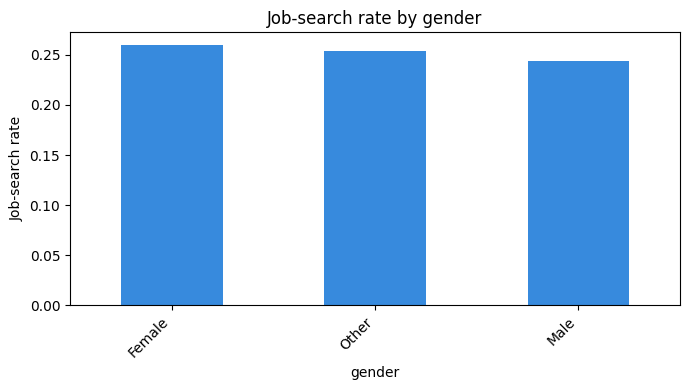

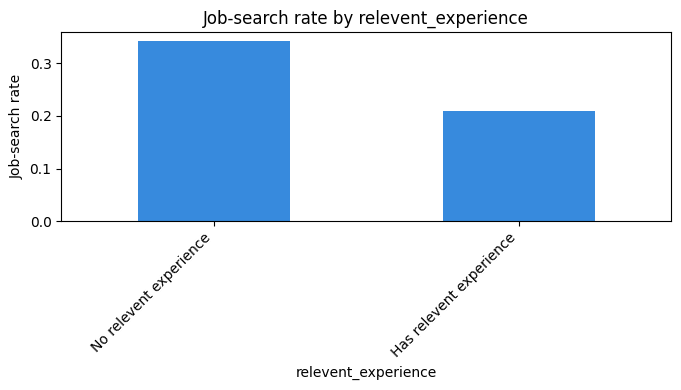

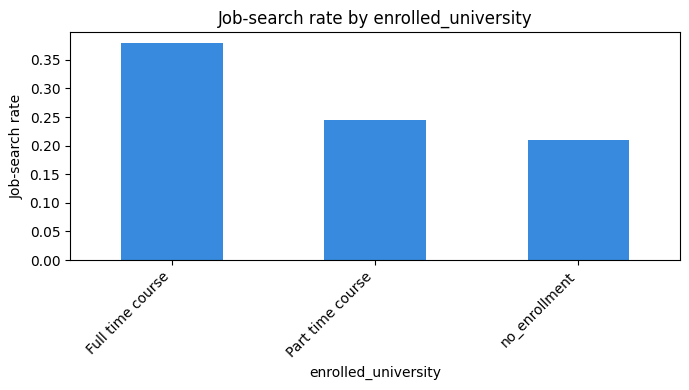

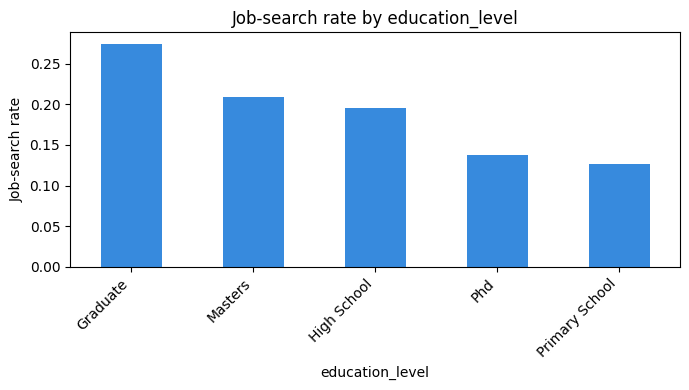

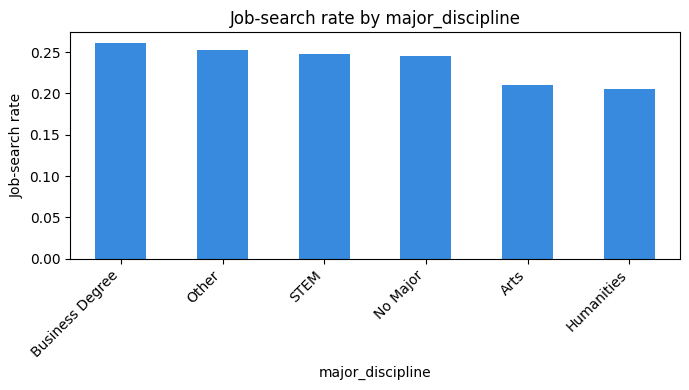

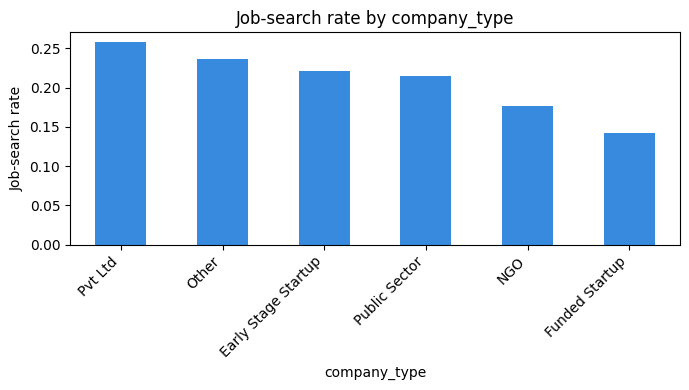

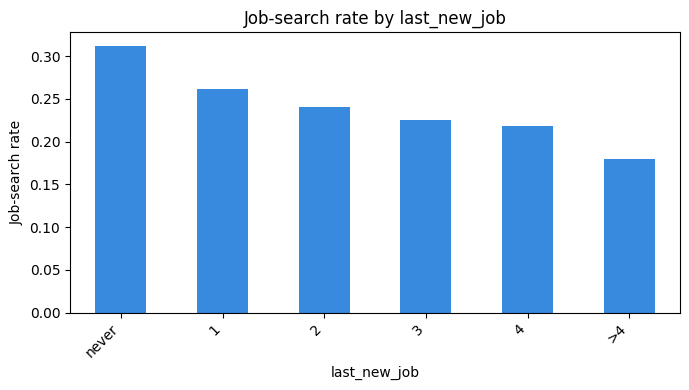

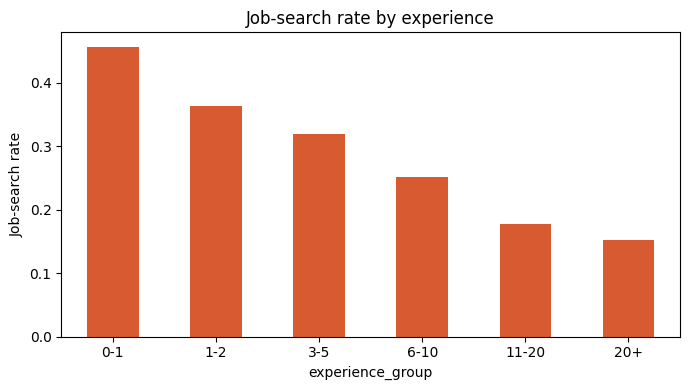

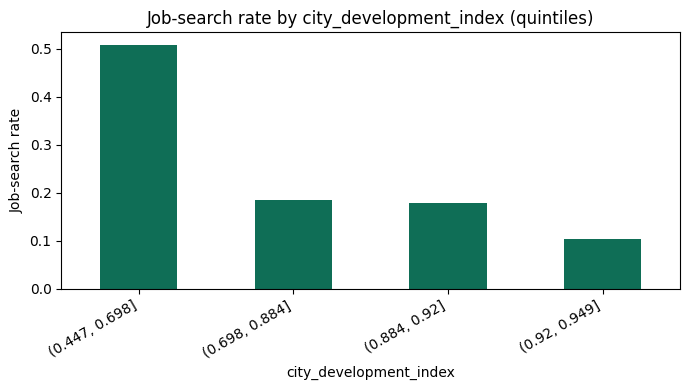

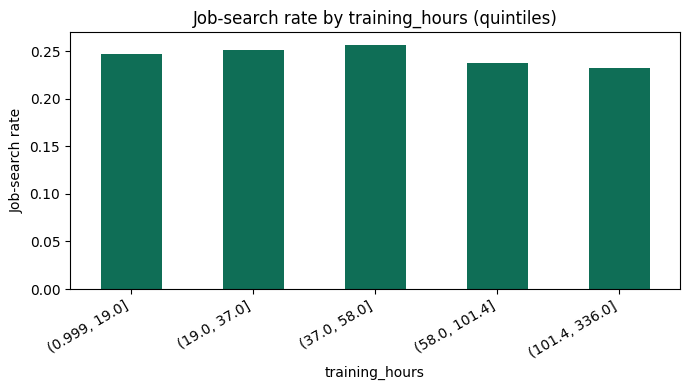

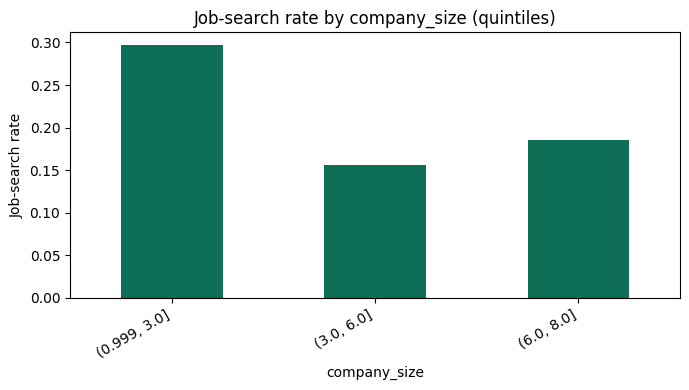

In [120]:
# ============================================================
# EDA: Each feature vs Target  (self-contained cell)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('aug_train.csv')
df['company_size'] = df['company_size'].fillna(df['company_size'].mode()[0])
df['company_size'] = df['company_size'].map({
    "<10":1, "10/49":2, "50-99":3, "100-500":4,
    "500-999":5, "1000-4999":6, "5000-9999":7, "10000+":8
})
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['company_type'] = df['company_type'].fillna(df['company_type'].mode()[0])
df['major_discipline'] = df['major_discipline'].fillna(df['major_discipline'].mode()[0])
df = df.dropna()

eda_df = df.copy()

# ---------- 1) categorical columns -> bar chart ----------
categorical_cols = [
    'gender', 'relevent_experience', 'enrolled_university', 'education_level',
    'major_discipline', 'company_type', 'last_new_job'
]

for col in categorical_cols:
    rate = eda_df.groupby(col)['target'].mean().sort_values(ascending=False)
    plt.figure(figsize=(7, 4))
    rate.plot(kind='bar', color='#378ADD')
    plt.title(f'Job-search rate by {col}')
    plt.ylabel('Job-search rate')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ---------- 2) experience (needs grouping) ----------
def exp_group(e):
    if e == '<1': return '0-1'
    if e == '>20': return '20+'
    e = int(e)
    if e <= 2: return '1-2'
    if e <= 5: return '3-5'
    if e <= 10: return '6-10'
    return '11-20'

order = ['0-1', '1-2', '3-5', '6-10', '11-20', '20+']
eda_df['experience_group'] = eda_df['experience'].apply(exp_group)
rate = eda_df.groupby('experience_group')['target'].mean().reindex(order)
plt.figure(figsize=(7, 4))
rate.plot(kind='bar', color='#D85A30')
plt.title('Job-search rate by experience')
plt.ylabel('Job-search rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- 3) continuous columns -> quintile buckets ----------
continuous_cols = ['city_development_index', 'training_hours', 'company_size']

for col in continuous_cols:
    eda_df[f'{col}_bucket'] = pd.qcut(eda_df[col], q=5, duplicates='drop')
    rate = eda_df.groupby(f'{col}_bucket', observed=True)['target'].mean()
    plt.figure(figsize=(7, 4))
    rate.plot(kind='bar', color='#0F6E56')
    plt.title(f'Job-search rate by {col} (quintiles)')
    plt.ylabel('Job-search rate')
    plt.xlabel(col)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

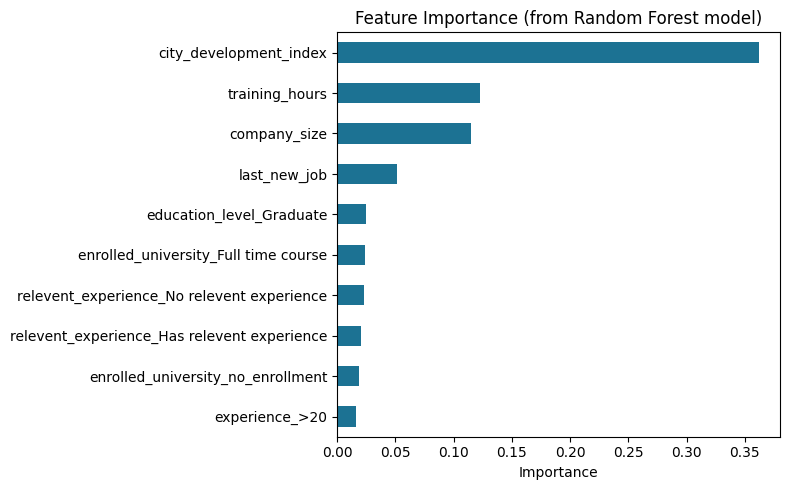

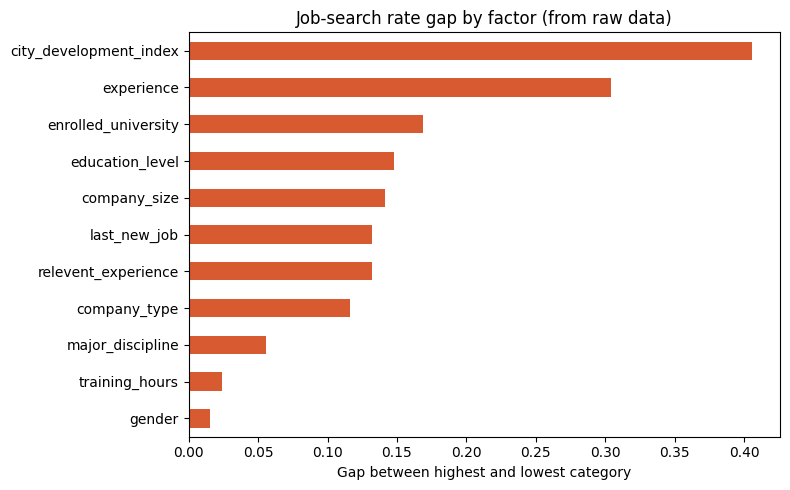

In [121]:
# ============================================================
# GRAPH 1: Feature Importance (from the MODEL)
# ============================================================
importances = pd.Series(rf_model.feature_importances_, index=x_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#1C7293')
plt.title('Feature Importance (from Random Forest model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2: Business Insights Gap (from the RAW DATA)
# ============================================================
factors = {}

def add_gap(name, rate):
    factors[name] = rate.max() - rate.min()

eda_df = df_before_encoding.copy()

add_gap('city_development_index', eda_df.groupby(pd.qcut(eda_df['city_development_index'], q=5, duplicates='drop'), observed=True)['target'].mean())

def exp_group(e):
    if e == '<1': return '0-1'
    if e == '>20': return '20+'
    e = int(e)
    if e <= 2: return '1-2'
    if e <= 5: return '3-5'
    if e <= 10: return '6-10'
    return '11-20'
eda_df['experience_group'] = eda_df['experience'].apply(exp_group)
add_gap('experience', eda_df.groupby('experience_group')['target'].mean())

add_gap('relevent_experience', eda_df.groupby('relevent_experience')['target'].mean())
add_gap('enrolled_university', eda_df.groupby('enrolled_university')['target'].mean())
add_gap('company_size', eda_df.groupby(pd.qcut(eda_df['company_size'], q=5, duplicates='drop'), observed=True)['target'].mean())
add_gap('last_new_job', eda_df.groupby('last_new_job')['target'].mean())
add_gap('education_level', eda_df.groupby('education_level')['target'].mean())
add_gap('company_type', eda_df.groupby('company_type')['target'].mean())
add_gap('gender', eda_df.groupby('gender')['target'].mean())
add_gap('major_discipline', eda_df.groupby('major_discipline')['target'].mean())
add_gap('training_hours', eda_df.groupby(pd.qcut(eda_df['training_hours'], q=5, duplicates='drop'), observed=True)['target'].mean())

gaps = pd.Series(factors).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
gaps.plot(kind='barh', color='#D85A30')
plt.title('Job-search rate gap by factor (from raw data)')
plt.xlabel('Gap between highest and lowest category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

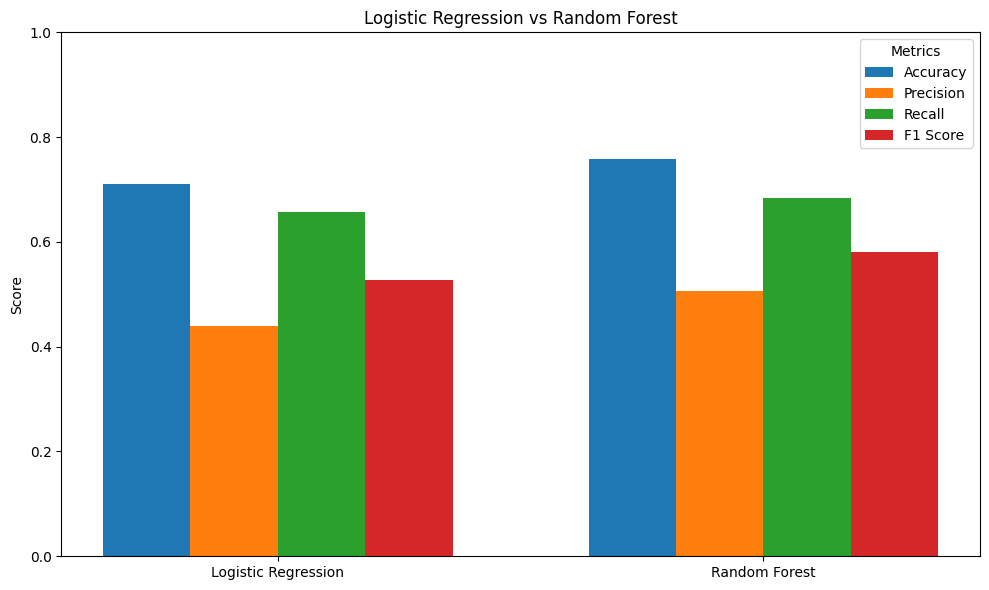

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# ضع قيمك هنا
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
logistic_scores = [accuracy_log, precision_log, recall_log, f1_log]
rf_scores = [accuracy_rf, precision_rf, recall_rf, f1_rf]

x = np.arange(2)  # موقع الموديلين على المحور الأفقي (0, 1)
bar_width = 0.18
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    values = [logistic_scores[i], rf_scores[i]]
    positions = x + (i - 1.5) * bar_width
    ax.bar(positions, values, width=bar_width, color=colors[i], label=metric)

ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Logistic Regression vs Random Forest')
ax.legend(title='Metrics')

plt.tight_layout()
plt.show()